# HU Lung Mask -- Step-by-Step

Replicates  from  on a single CT slice.

**Pipeline:**
1. Threshold (HU < -500)
2. Label connected regions
3. Remove border-touching regions (background air)
4. Re-label internal regions
5. Keep 2 largest (left + right lung)
6. Label left vs right by centroid column position
7. Combine left | right, dilate with disk(3)


In [1]:
%matplotlib inline
import pylidc as pl
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import label, binary_dilation, center_of_mass
from skimage.morphology import disk as morpho_disk

plt.rcParams["figure.figsize"] = (7, 7)
plt.rcParams["image.cmap"] = "gray"

LUNG_HU_THRESHOLD = -500
HU_MIN = -1000
HU_MAX  =  400


## Load one scan, get one slice

CT volume axes: `(rows, cols, slices)` -- we take the middle slice.

In [2]:
scan = pl.query(pl.Scan).first()
vol  = scan.to_volume()

slice_idx = vol.shape[2] // 2
raw_slice = vol[:, :, slice_idx].astype(np.float32)

print(f"Patient:      {scan.patient_id}")
print(f"Volume shape: {vol.shape}")
print(f"Slice chosen: {slice_idx} of {vol.shape[2]}")
print(f"HU range:     {raw_slice.min():.0f} to {raw_slice.max():.0f}")

Loading dicom files ... This may take a moment.
Patient:      LIDC-IDRI-0078
Volume shape: (512, 512, 87)
Slice chosen: 43 of 87
HU range:     -2048 to 1398


## Original CT slice

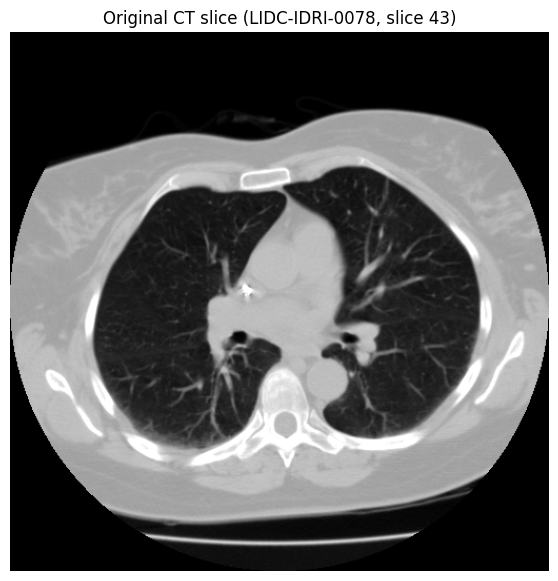

In [3]:
def normalize_for_display(img, hu_min=HU_MIN, hu_max=HU_MAX):
    clipped = np.clip(img, hu_min, hu_max)
    return (clipped - hu_min) / (hu_max - hu_min)

display = normalize_for_display(raw_slice)

plt.imshow(display)
plt.title(f"Original CT slice ({scan.patient_id}, slice {slice_idx})")
plt.axis("off")
plt.show()

## Step 1 -- Threshold at HU < -500

Everything below -500 HU is air-like: lungs, trachea, and outside background.

Pixels below -500 HU: 148651 / 262144


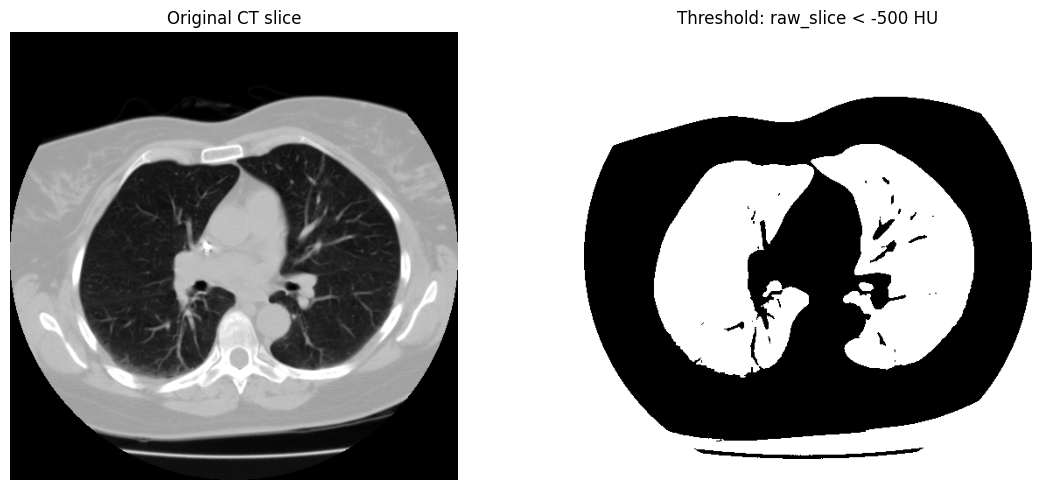

In [4]:
binary = raw_slice < LUNG_HU_THRESHOLD
print(f"Pixels below {LUNG_HU_THRESHOLD} HU: {binary.sum()} / {binary.size}")

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].imshow(display)
ax[0].set_title("Original CT slice")
ax[0].axis("off")
ax[1].imshow(binary)
ax[1].set_title(f"Threshold: raw_slice < {LUNG_HU_THRESHOLD} HU")
ax[1].axis("off")
plt.tight_layout()
plt.show()

## Step 2 -- Label all connected regions

Connected regions found: 6


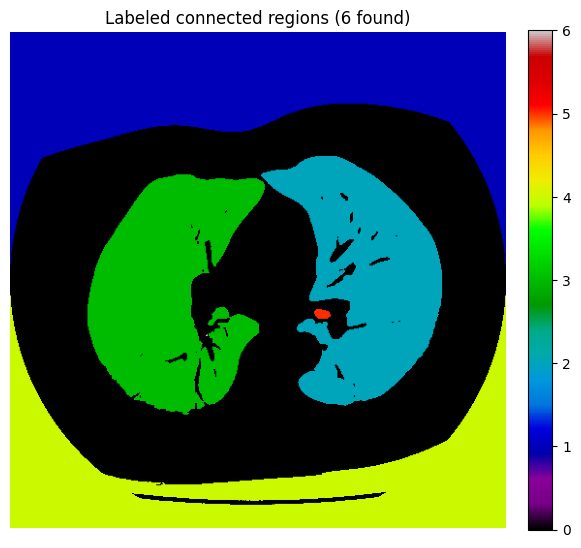

In [5]:
labeled, num_features = label(binary)
print(f"Connected regions found: {num_features}")

plt.figure(figsize=(7, 7))
plt.imshow(labeled, cmap="nipy_spectral")
plt.title(f"Labeled connected regions ({num_features} found)")
plt.colorbar(fraction=0.046, pad=0.04)
plt.axis("off")
plt.show()

## Step 3 -- Remove border-touching regions (background air)

Outside air touches the image border; lungs sit inside the body and do not.

Border-touching labels: [np.int32(1), np.int32(4)]


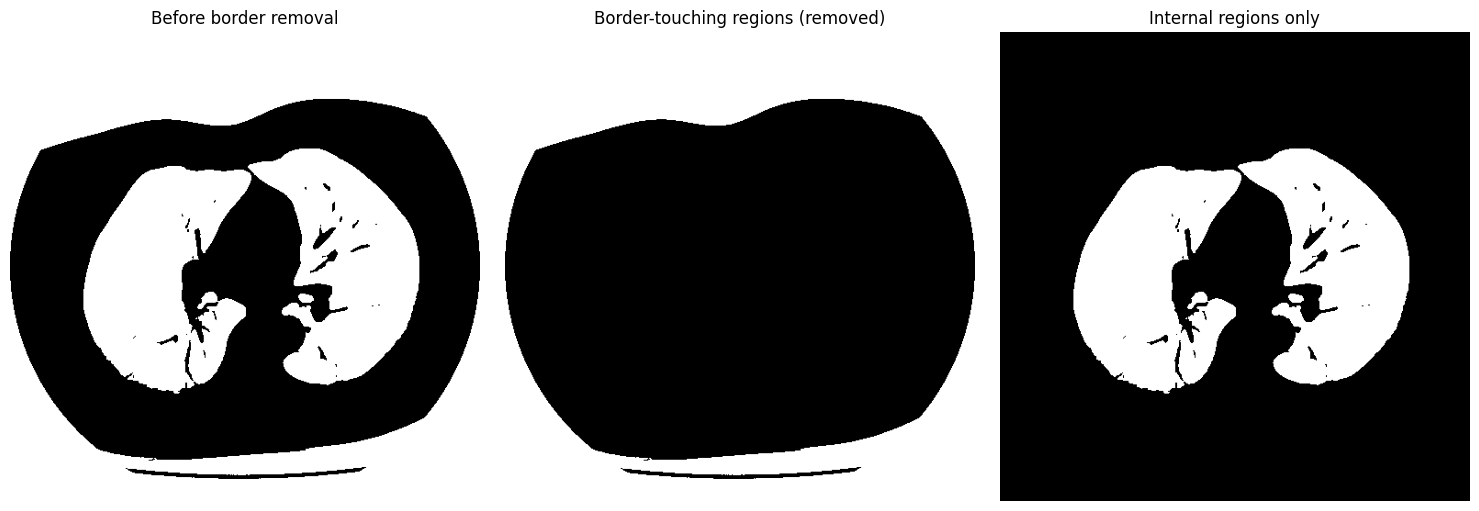

In [6]:
border_labels = set()
border_labels.update(labeled[0, :])
border_labels.update(labeled[-1, :])
border_labels.update(labeled[:, 0])
border_labels.update(labeled[:, -1])
border_labels.discard(0)
print(f"Border-touching labels: {sorted(border_labels)}")

border_mask = np.isin(labeled, list(border_labels))

labeled_no_border = labeled.copy()
for lbl in border_labels:
    labeled_no_border[labeled_no_border == lbl] = 0
binary_internal = labeled_no_border > 0

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(binary)
ax[0].set_title("Before border removal")
ax[0].axis("off")
ax[1].imshow(border_mask)
ax[1].set_title("Border-touching regions (removed)")
ax[1].axis("off")
ax[2].imshow(binary_internal)
ax[2].set_title("Internal regions only")
ax[2].axis("off")
plt.tight_layout()
plt.show()

## Step 4 -- Re-label internal regions

Internal regions after border removal: 4


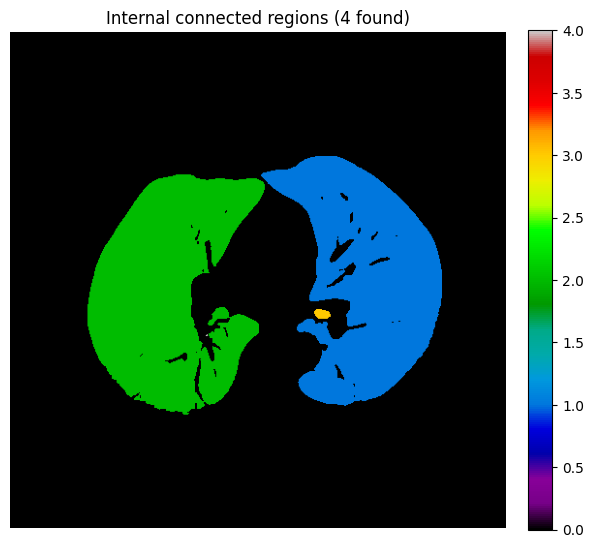

In [7]:
labeled2, num2 = label(binary_internal)
print(f"Internal regions after border removal: {num2}")

plt.figure(figsize=(7, 7))
plt.imshow(labeled2, cmap="nipy_spectral")
plt.title(f"Internal connected regions ({num2} found)")
plt.colorbar(fraction=0.046, pad=0.04)
plt.axis("off")
plt.show()

## Step 5 -- Keep the 2 largest internal regions

`np.bincount` counts pixels per label in one pass. Each lung is kept as its own
separate mask -- they are **not** combined yet.

Region sizes (pixels):
  Label 1: 26863 px
  Label 2: 28917 px
  Label 3: 133 px
  Label 4: 3 px
Keeping labels: [2 1]


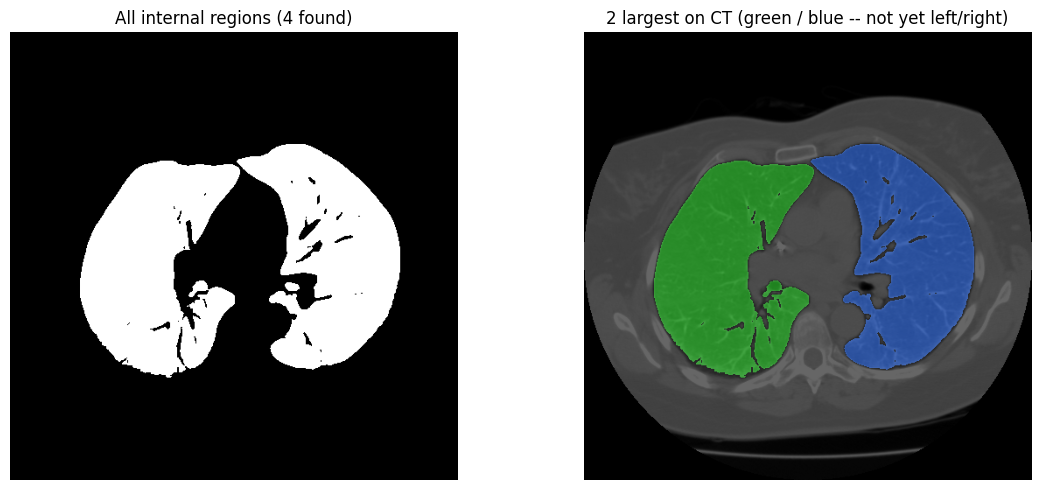

In [8]:
if num2 == 0:
    print("No internal regions -- mask will be empty.")
    lung_regions = []
    keep_labels  = []
else:
    region_sizes = np.bincount(labeled2.ravel())[1:]  # drop index 0 (background)
    print("Region sizes (pixels):")
    for i, sz in enumerate(region_sizes, start=1):
        print(f"  Label {i}: {int(sz)} px")

    n_keep = min(2, len(region_sizes))
    sorted_idx  = np.argsort(region_sizes)[::-1]
    keep_labels = sorted_idx[:n_keep] + 1
    print(f"Keeping labels: {keep_labels}")

    lung_regions = [labeled2 == lbl for lbl in keep_labels]

# Show each region individually on the CT
region_colours = [[0.2, 0.85, 0.2], [0.2, 0.45, 0.95]]
colour_img = np.zeros((*display.shape, 3), dtype=np.float32)
for region, col in zip(lung_regions, region_colours):
    colour_img[region] = col

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].imshow(binary_internal, cmap="gray")
ax[0].set_title(f"All internal regions ({num2} found)")
ax[0].axis("off")
ax[1].imshow(display, cmap="gray")
ax[1].imshow(colour_img, alpha=0.6)
ax[1].set_title("2 largest on CT (green / blue -- not yet left/right)")
ax[1].axis("off")
plt.tight_layout()
plt.show()

## Step 6 -- Label left vs right lung by centroid column position

The centroid column (`center_of_mass(...)[1]`) determines left vs right:
lower column index = left, higher = right.

Each lung is tracked separately so later dilation **cannot bridge
the mediastinal gap** between them.

Left lung  centroid col: 164.2
Right lung centroid col: 365.9


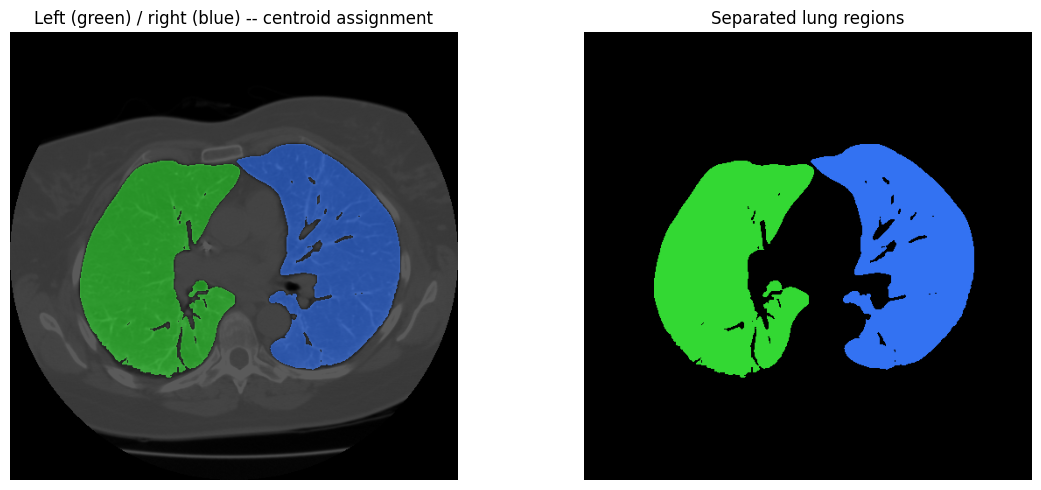

In [9]:
if len(lung_regions) == 2:
    cx = [center_of_mass(m)[1] for m in lung_regions]
    left_mask  = lung_regions[int(np.argmin(cx))]
    right_mask = lung_regions[int(np.argmax(cx))]
    lungs = [left_mask, right_mask]
    print(f"Left lung  centroid col: {min(cx):.1f}")
    print(f"Right lung centroid col: {max(cx):.1f}")
elif len(lung_regions) == 1:
    left_mask  = lung_regions[0]
    right_mask = None
    lungs = [left_mask]
    print("Only one region found.")
else:
    left_mask = right_mask = None
    lungs = []
    print("No regions.")

colour_lr = np.zeros((*display.shape, 3), dtype=np.float32)
if left_mask  is not None: colour_lr[left_mask]  = [0.2, 0.85, 0.2]
if right_mask is not None: colour_lr[right_mask] = [0.2, 0.45, 0.95]

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].imshow(display, cmap="gray")
ax[0].imshow(colour_lr, alpha=0.65)
ax[0].set_title("Left (green) / right (blue) -- centroid assignment")
ax[0].axis("off")
ax[1].imshow(colour_lr)
ax[1].set_title("Separated lung regions")
ax[1].axis("off")
plt.tight_layout()
plt.show()

## Step 7 -- Combine masks and dilate with disk(3)

Union the left and right lung masks, then expand the boundary
with a morphological dilation using a disk structuring element of radius 3.

Combined: 55780 px  |  After disk(3): 62290 px (23.8%)


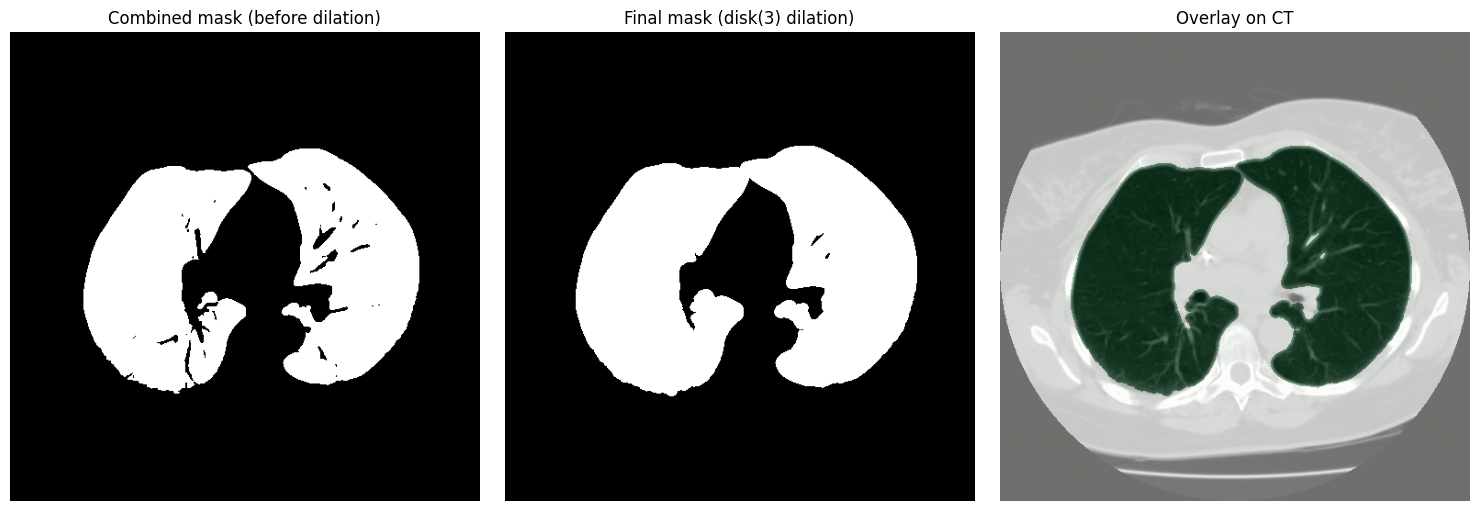

In [10]:
combined = np.zeros(raw_slice.shape, dtype=bool)
if left_mask is not None:
    combined |= left_mask
if right_mask is not None:
    combined |= right_mask

clean_mask = binary_dilation(combined, structure=morpho_disk(3)).astype("uint8")

print(f"Combined: {combined.sum()} px  |  After disk(3): {clean_mask.sum()} px "
      f"({100*clean_mask.sum()/clean_mask.size:.1f}%)")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(combined, cmap="gray")
axes[0].set_title("Combined mask (before dilation)")
axes[0].axis("off")
axes[1].imshow(clean_mask, cmap="gray")
axes[1].set_title("Final mask (disk(3) dilation)")
axes[1].axis("off")
axes[2].imshow(display, cmap="gray")
axes[2].imshow(clean_mask, cmap="Greens", alpha=0.45)
axes[2].set_title("Overlay on CT")
axes[2].axis("off")
plt.tight_layout()
plt.show()


## Summary -- full pipeline

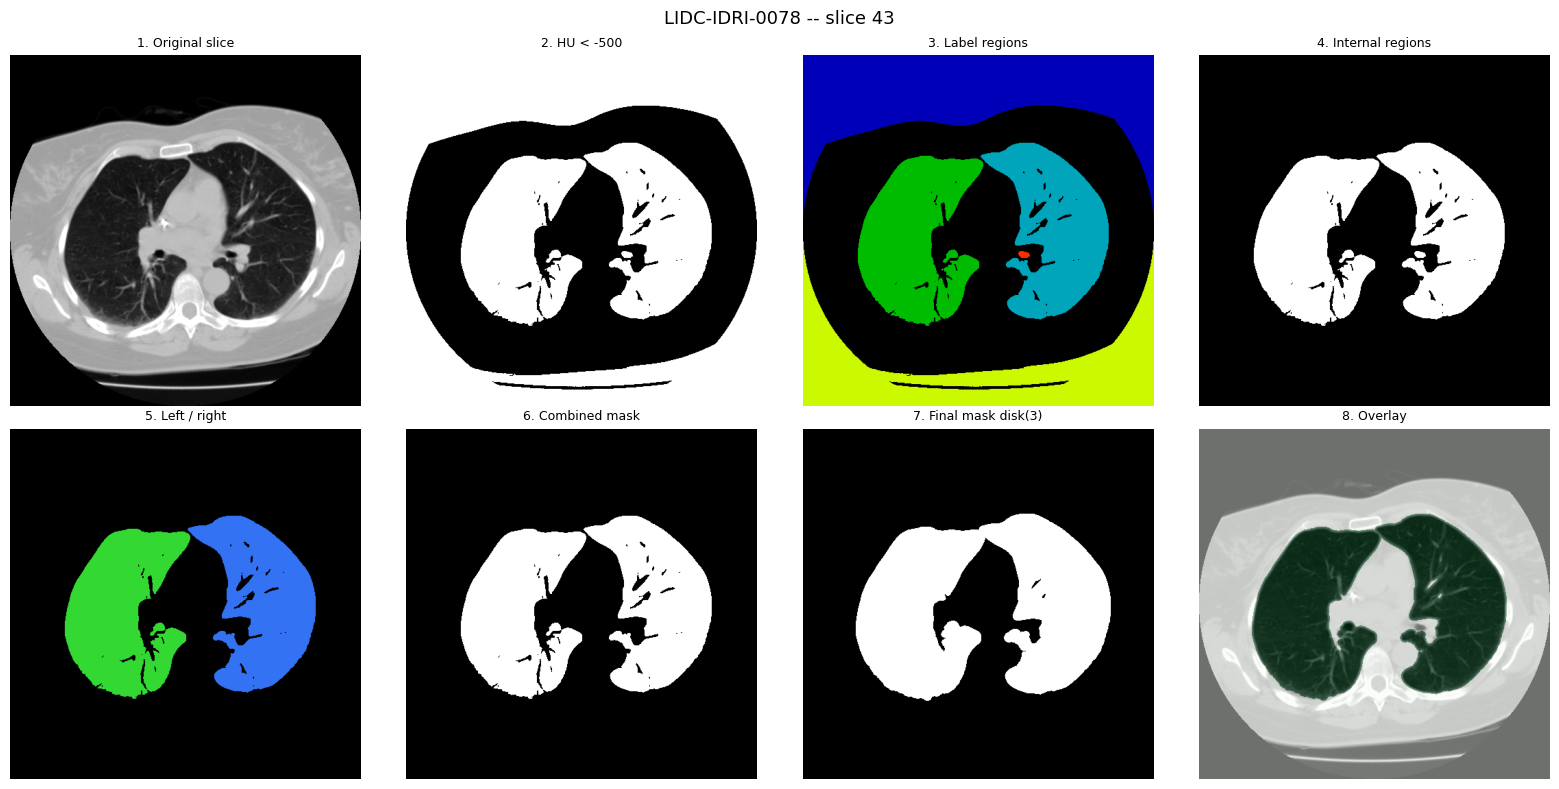

In [11]:
colour_lr_s = np.zeros((*display.shape, 3), dtype=np.float32)
if left_mask  is not None: colour_lr_s[left_mask]  = [0.2, 0.85, 0.2]
if right_mask is not None: colour_lr_s[right_mask] = [0.2, 0.45, 0.95]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
steps = [
    (display,         "1. Original slice",             "gray"),
    (binary,          f"2. HU < {LUNG_HU_THRESHOLD}", "gray"),
    (labeled,         "3. Label regions",              "nipy_spectral"),
    (binary_internal, "4. Internal regions",           "gray"),
    (colour_lr_s,     "5. Left / right",               None),
    (combined,        "6. Combined mask",              "gray"),
    (clean_mask,      "7. Final mask disk(3)",         "gray"),
    (display,         "8. Overlay",                    "gray"),
]
for i, (ax, (img, title, cmap)) in enumerate(zip(axes.ravel(), steps)):
    if cmap:
        ax.imshow(img, cmap=cmap)
    else:
        ax.imshow(img)
    if i == 7:
        ax.imshow(clean_mask, cmap="Greens", alpha=0.45)
    ax.set_title(title, fontsize=9)
    ax.axis("off")
plt.suptitle(f"{scan.patient_id} -- slice {slice_idx}", fontsize=13)
plt.tight_layout()
plt.show()
